In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import time
import os
import math

from jaqalpaq import run
from jaqalpaq import emulator
from jaqalpaq.run import run_jaqal_file, run_jaqal_string, run_jaqal_batch, run_jaqal_circuit, frontend

from jaqalpaq.emulator.unitary import UnitarySerializedEmulator
emulator_backend = UnitarySerializedEmulator()
from qscout.v1.std.noisy import SNLToy1

from jaqalpaq.qsyntax import circuit
from jaqalpaq.generator import generate_jaqal_program
from jaqalpaq.core.algorithm import expand_subcircuits

from qscout.v1.std.noisy import SNLToy1

In [2]:
#Define your Jaqal circuit

jaqal_string = """from Calibration_PulseDefinitions.UserPulses usepulses *

let pi   3.1415926535897
let pi_2 1.57079
let num_gates 2
let ms_angle 1.57079

register q[2]
subcircuit{

loop num_gates{
    //Sy q[1]
    MS q[0] q[1] 0 ms_angle
}

}
"""

In [ ]:
# Physical bounds
AMP_IA_MIN,   AMP_IA_MAX   = 0.0,   100.0
ZETA_MIN,     ZETA_MAX     = 0.5,     1.5
FRAMEROT_MIN, FRAMEROT_MAX = -180.0, 180.0
SIDEBAND_OFFSET_MIN, SIDEBAND_OFFSET_MAX = -5000, 5000
CARRIER_OFFSET_MIN, CARRIER_OFFSET_MAX = -5000, 5000

# Gate parameters
NUM_GATES    = 2
MS_ANGLE     = math.pi / 2

# Run emulator on hardware or toy problem 
emulator = True   # set False to run on hardware

In [ ]:
def jaqal_objective(u, N: int):
    """
    u[0] → amp_ia   in [0,   100]
    u[1] → zeta     in [0.5, 1.5]
    u[2] → framerot in [-180, 180]

    Returns population probabilities (p00, p01, p10, p11).
    Julia converts these to the calibration score via score_mode.
    """
    u = np.asarray(u, dtype=float)

    # Denormalize parameters (need to normalize for surrogate model)
    amp_ia   = AMP_IA_MIN   + (u[0] + 1.0) / 2.0 * (AMP_IA_MAX   - AMP_IA_MIN) #Typically a max of 100, since the amplitude and zeta are intertwined (and diff per qubit), we'll need to think more about how to properly bound this
    zeta     = ZETA_MIN     + (u[1] + 1.0) / 2.0 * (ZETA_MAX     - ZETA_MIN) #blue/red ratio, usually around 1.05
    framerot = FRAMEROT_MIN + (u[2] + 1.0) / 2.0 * (FRAMEROT_MAX - FRAMEROT_MIN) #light shift correction, -180 to 180 degrees
    sideband_offset = SIDEBAND_OFFSET_MIN + (u[3] + 1.0) / 2.0 * (SIDEBAND_OFFSET_MAX - SIDEBAND_OFFSET_MIN)
    carrier_offset = CARRIER_OFFSET_MIN + (u[4] + 1.0) / 2.0 * (CARRIER_OFFSET_MAX - CARRIER_OFFSET_MIN)


    #Here we're defining a simple error model based on Jaqal's SNLToy1
    delta_theta = (amp_ia*(np.pi/80) - np.pi/2) / 10 #SNLToy1 is silly, it multiples the rotation error by a factor of 10 for all two qubit gates, same for depolarization and phase error
    depolarization = 2e-5+2e-2*(zeta-1.05)**2
    #delta_phi = (framerot + 20) #Couldn't get framerot to act properly in this simple error model
    noisy_model = SNLToy1(2,rotation_error=delta_theta, depolarization = depolarization) #phase_error = delta_phi)

    if emulator:
        
        #Define the override dictionary to change parameters in the jaqal file
        overrides = {
            "ms_angle":    MS_ANGLE,
            "num_gates":   NUM_GATES,
            "__repeats__": N,
        }

        # Emulator version swaps the pulse library
        jaqal_emulator = jaqal_string.replace(
            "from Calibration_PulseDefinitions.UserPulses usepulses *",
            "from qscout.v1.std usepulses *",
        )
        #Run and return results object
        results = run_jaqal_string(jaqal_emulator, backend=noisy_model,
                                   overrides=overrides)
        
        #Extract probabilities from the results object
        probs = results.subcircuits[0].probability_by_int #00,01,10,11 (right-most qubit is q[0], left-most is q[1])
    else:
        #Define the override dictionary to change parameters in the jaqal file AND the pulse definitions "pd."
        overrides={'pd.amp_ia': amp_ia,
                   'pd.zeta': zeta,
                   #'pd.framerot': framerot,
                   'pd.sideband_offset': sideband_offset,
                   'pd.carrier_offset': carrier_offset,
                   'ms_angle': MS_ANGLE,
                   'num_gates': NUM_GATES,
                   '__repeats__': N}
        #Run and return results object
        results = run.run_jaqal_string(jaqal_string, overrides=overrides)
        #Extract probabilities from the results object NOTE: The formatting of the results object is sometimes a little different on the experiment vs. the emulator (extra nesting), so we'll need to confirm the actual object shaping
        probs = results.subcircuits[0].probability_by_int #00,01,10,11 (right-most qubit is q[0], left-most is q[1])

    # Return full population vector; Julia applies score_mode (:p11 or :full_l1)
    return probs

In [5]:
# Load the Julia surrogate model and optimizer
from juliacall import Main as jl
_repo_root = os.getcwd()
jl.seval(f'import Pkg; Pkg.activate("{_repo_root}"; io=devnull)')
jl.seval('Pkg.instantiate(; io=devnull)')
jl.seval(f'include("{os.path.join(_repo_root, "src", "bayes_hetero_opt.jl")}")')

print("Julia BO loaded.")

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


┌ Warning: The active manifest file has dependencies that were resolved with a different julia version (1.11.6). Unexpected behavior may occur.
└ @ ~/Documents/SQRL/Calibration/QFO-sandia/Manifest.toml:0
┌ Warning: The project dependencies or compat requirements have changed since the manifest was last resolved.
│ It is recommended to `Pkg.resolve()` or consider `Pkg.update()` if necessary.
└ @ Pkg.API ~/.julia/juliaup/julia-1.12.6+0.aarch64.apple.darwin14/Julia-1.12.app/Contents/Resources/julia/share/julia/stdlib/v1.12/Pkg/src/API.jl:1322
┌ Error: Error during loading of extension StructUtilsStaticArraysCoreExt of StructUtils, use `Base.retry_load_extensions()` to retry.
│   exception =
│    1-element ExceptionStack:
│    ArgumentError: Package StructUtilsStaticArraysCoreExt [5f8627f4-f0c5-5aac-996c-f7a3cc29134a] is required but does not seem to be installed:
│     - Run `Pkg.instantiate()` to install all recorded dependencies.
│    
│    Stacktrace:
│      [1] __require_prelocked(pkg

Julia BO loaded.


In [6]:
# --- Experiment sweep ---
from pickle import FALSE


N_LIST = [100, 1000]   # shots per evaluation (matches __repeats__ in Jaqal)
EXPERIMENTS_PER_N = 5              # independent BO runs per N (distinct seeds)
SCORE_MODE = "full_l1"              # "full_l1" or "p11"

# --- BO tunables ---
N_INIT = 12                         # random initial evaluations before GP is fitted
N_ITER = 75                         # max BO iterations after initialisation
KAPPA = 1.96                        # UCB exploration weight (κ)
HYPER_EVERY = 10                    # re-optimise GP hyperparameters every N iterations
N_RESTARTS = 5                      # random restarts for hyperparameter optimisation
FIDELITY_THRESH = None              # early-stop when measured score ≥ threshold, e.g. 0.98
LEARN_NOISE_SCALE = True
JITTER = 1e-8                       # GP Cholesky jitter (not α — this optimizer has no α knob)
BASE_SEED = 42

# --- Restart on GP-LCB stagnation (ported from QFO trace logic) ---
RESTART_ON_STAGNATION = False
RESTART_FAILURE_WINDOW = 14         # consecutive stagnant iterations before restart
RESTART_MIN_ACTIVE_ITER = 20        # minimum iterations since last restart
RESTART_MIN_DELTA = 0.02            # required LCB improvement to reset failure counter
RESTART_DISABLE_LCB = 0.85          # LCB above this → doing well, reset failure counter
RESTART_MAX_RESTARTS = 3
RESTART_CONFIDENCE_Z = 1.0          # z for m_rec_lcb = m_rec - z * s_rec

# Normalised bounds [-1, 1]^3 passed to Julia
bounds = [(-1.0, 1.0), (-1.0, 1.0), (-1.0, 1.0)]
jl_bounds = jl.seval("Vector{Tuple{Float64,Float64}}")([tuple(b) for b in bounds])

In [7]:
# Julia BO wrapper + N-sweep experiment
jl.seval("""
function _run_bo(f, bounds, n_shots, n_init, n_iter, kap, seed_val,
                 hyper_every, n_restarts, fid_thresh, score_mode, learn_noise, jitter,
                 restart_on, restart_window, restart_min_active, restart_min_delta,
                 restart_disable_lcb, restart_max, restart_conf_z)
    restart_cfg = RestartConfig(;
        enabled=restart_on,
        failure_window=restart_window,
        min_active_iter=restart_min_active,
        min_delta=restart_min_delta,
        disable_lcb=restart_disable_lcb,
        max_restarts=restart_max,
        confidence_z=restart_conf_z,
    )
    bayesopt_ucb_threshold(f;
        bounds=bounds,
        n_shots=n_shots,
        n_init=n_init,
        n_iter=n_iter,
        κ=kap,
        seed=seed_val,
        maximize=true,
        fidelity_threshold=fid_thresh,
        hyper_every=hyper_every,
        learn_noise_scale=learn_noise,
        n_restarts=n_restarts,
        score_mode=score_mode,
        jitter=jitter,
        restart_config=restart_cfg,
    )
end
""")

def u_to_physical(u):
    u = np.asarray(u, dtype=float)
    amp_ia = AMP_IA_MIN + (u[0] + 1.0) / 2.0 * (AMP_IA_MAX - AMP_IA_MIN)
    zeta = ZETA_MIN + (u[1] + 1.0) / 2.0 * (ZETA_MAX - ZETA_MIN)
    framerot = FRAMEROT_MIN + (u[2] + 1.0) / 2.0 * (FRAMEROT_MAX - FRAMEROT_MIN)
    return amp_ia, zeta, framerot

def record_run(result, n_shots, seed, elapsed):
    X_opt = np.array(result.X_opt)          # (d, n_iter) normalized recommended points
    u_last = X_opt[:, -1]
    amp_last, zeta_last, frame_last = u_to_physical(u_last)
    return {
        "N": int(n_shots),
        "seed": int(seed),
        "score": float(result.y_last_opt),
        "mu_last": float(result.mu_opt[-1]),
        "n_iter": int(result.n_iter_actual),
        "total_shots": int(result.total_shots),
        "elapsed_s": float(elapsed),
        "amp_ia": float(amp_last),
        "zeta": float(zeta_last),
        "framerot": float(frame_last),
        "X_opt": X_opt,
        "n_restarts": int(result.n_restarts),
    }

score_mode_jl = jl.seval(f'Symbol("{SCORE_MODE}")')
learn_noise_jl = bool(LEARN_NOISE_SCALE)
fid_julia = jl.nothing if FIDELITY_THRESH is None else float(FIDELITY_THRESH)

all_runs = []
run_idx = 0
for n_shots in N_LIST:
    for rep in range(EXPERIMENTS_PER_N):
        seed = BASE_SEED + run_idx
        run_idx += 1
        t0 = time.time()
        result = jl._run_bo(
            jaqal_objective,
            jl_bounds,
            int(n_shots),
            int(N_INIT),
            int(N_ITER),
            float(KAPPA),
            int(seed),
            int(HYPER_EVERY),
            int(N_RESTARTS),
            fid_julia,
            score_mode_jl,
            learn_noise_jl,
            float(JITTER),
            bool(RESTART_ON_STAGNATION),
            int(RESTART_FAILURE_WINDOW),
            int(RESTART_MIN_ACTIVE_ITER),
            float(RESTART_MIN_DELTA),
            float(RESTART_DISABLE_LCB),
            int(RESTART_MAX_RESTARTS),
            float(RESTART_CONFIDENCE_Z),
        )
        elapsed = time.time() - t0
        rec = record_run(result, n_shots, seed, elapsed)
        all_runs.append(rec)
        print(
            f"N={n_shots} rep={rep + 1}/{EXPERIMENTS_PER_N} seed={seed} "
            f"score={rec['score']:.4f} shots={rec['total_shots']} "
            f"iters={rec['n_iter']} restarts={rec['n_restarts']} time={elapsed:.1f}s"
        )

print(f"\nCompleted {len(all_runs)} runs.")

N=100 rep=1/5 seed=42 score=0.9993 shots=8800 iters=75 restarts=0 time=9.7s
N=100 rep=2/5 seed=43 score=0.9994 shots=8800 iters=75 restarts=0 time=7.3s
N=100 rep=3/5 seed=44 score=0.9994 shots=8800 iters=75 restarts=0 time=7.2s
N=100 rep=4/5 seed=45 score=0.9995 shots=8800 iters=75 restarts=0 time=7.3s
N=100 rep=5/5 seed=46 score=0.9995 shots=8800 iters=75 restarts=0 time=7.2s
N=1000 rep=1/5 seed=47 score=0.9995 shots=88000 iters=75 restarts=0 time=7.9s
N=1000 rep=2/5 seed=48 score=0.9994 shots=88000 iters=75 restarts=0 time=7.9s
N=1000 rep=3/5 seed=49 score=0.9994 shots=88000 iters=75 restarts=0 time=7.9s
N=1000 rep=4/5 seed=50 score=0.9995 shots=88000 iters=75 restarts=0 time=7.6s
N=1000 rep=5/5 seed=51 score=0.9995 shots=88000 iters=75 restarts=0 time=8.0s

Completed 10 runs.


In [12]:
# Aggregate results across N and repeats
from datetime import datetime
from pathlib import Path
import pandas as pd

df = pd.DataFrame(all_runs)
summary = df.groupby("N").agg(
    score_mean=("score", "mean"),
    score_std=("score", "std"),
    shots_mean=("total_shots", "mean"),
    shots_std=("total_shots", "std"),
    iters_mean=("n_iter", "mean"),
    elapsed_mean=("elapsed_s", "mean"),
).reset_index()

# Persist the full dataframe for future analysis, including array-valued columns like X_opt.
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)
run_prefix = f"bo_sweep"

full_df_path = results_dir / f"{run_prefix}.pkl"


df.to_pickle(full_df_path)

print(f"score_mode={SCORE_MODE}, {EXPERIMENTS_PER_N} runs per N\n")
print(summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\nSaved results:")
print(f"  full dataframe:   {full_df_path}")
df.head()

score_mode=full_l1, 5 runs per N

   N  score_mean  score_std  shots_mean  shots_std  iters_mean  elapsed_mean
 100      0.9994     0.0001   8800.0000     0.0000     75.0000        7.7212
1000      0.9994     0.0000  88000.0000     0.0000     75.0000        7.8607

Saved results:
  full dataframe:   results/bo_sweep.pkl


,N,seed,score,mu_last,n_iter,total_shots,elapsed_s,amp_ia,zeta,framerot,X_opt,n_restarts
0,100,42,0.999345,0.999728,75,8800,9.664842,40.305645,1.045317,-167.558841,"[[-0.20420101906784804, -0.2039856495163046, -...",0
1,100,43,0.999425,0.999360,75,8800,7.269447,39.836767,1.058291,-147.054092,"[[-0.16639772581329293, -0.1934048822226191, -...",0
2,100,44,0.999432,0.999492,75,8800,7.161754,40.174082,1.056497,4.878107,"[[-0.20636801044671982, -0.20679437426675973, ...",0
3,100,45,0.999494,0.999468,75,8800,7.327034,39.936369,1.049224,-72.284030,"[[-0.22862562287882682, -0.19011696955507196, ...",0
4,100,46,0.999494,0.999741,75,8800,7.182982,39.954100,1.047473,-168.579524,"[[-0.1636939749202555, -0.18935903868635995, -...",0


In [9]:
# Recommended-path plotting helpers
TARGET_INDEX = 3            # |11> population (native target), order is 00,01,10,11
FLOOR = 1e-5

def pop_infidelity_path(X_opt, N_eval):
    vals = []
    for k in range(X_opt.shape[1]):
        probs = np.asarray(jaqal_objective(X_opt[:, k], N_eval), dtype=float)
        vals.append(max(1.0 - probs[TARGET_INDEX], FLOOR))
    return np.array(vals)

def layered_band(ax, n, data, color, label=None):
    med = np.nanmedian(data, axis=0)
    for q in np.linspace(0.05, 0.45, 15):
        lo = np.nanquantile(data, q, axis=0)
        hi = np.nanquantile(data, 1 - q, axis=0)
        ax.fill_between(n, lo, hi, color=color, alpha=0.5 / 15, lw=0, zorder=1)
    ax.plot(n, med, "-", c=color, lw=2.0, zorder=2, label=label)
    return med

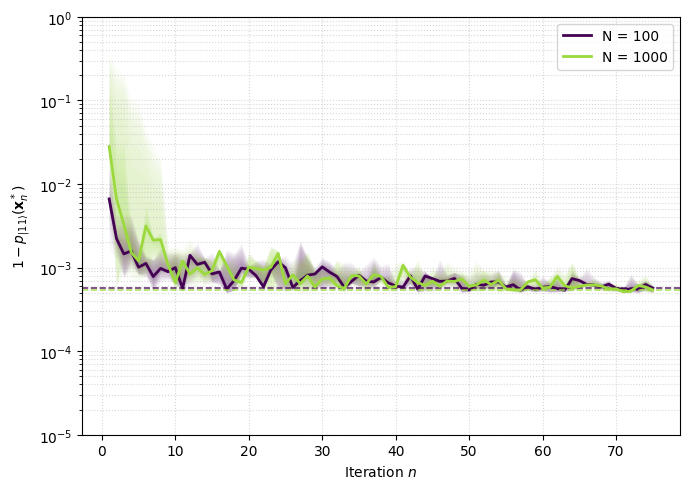

In [10]:
# Convergence trend: 1 - p11 along recommended path x_n* (one curve per N)
colors = plt.cm.viridis(np.linspace(0, 0.85, len(N_LIST)))
fig, ax = plt.subplots(figsize=(7, 5))

for c, N in zip(colors, N_LIST):
    rows = [r for r in all_runs if r["N"] == N]
    paths = np.vstack([pop_infidelity_path(r["X_opt"], N) for r in rows])
    n = np.arange(1, paths.shape[1] + 1)
    med = layered_band(ax, n, paths, c, label=f"N = {N}")
    ax.axhline(med[-1], color=c, ls="--", lw=1.2, alpha=0.8)

ax.set_yscale("log")
ax.set_ylim(FLOOR, 1.0)
ax.set_xlabel("Iteration $n$")
ax.set_ylabel(r"$1 - p_{|11\rangle}(\mathbf{x}^*_n)$")
ax.grid(True, which="both", ls=":", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

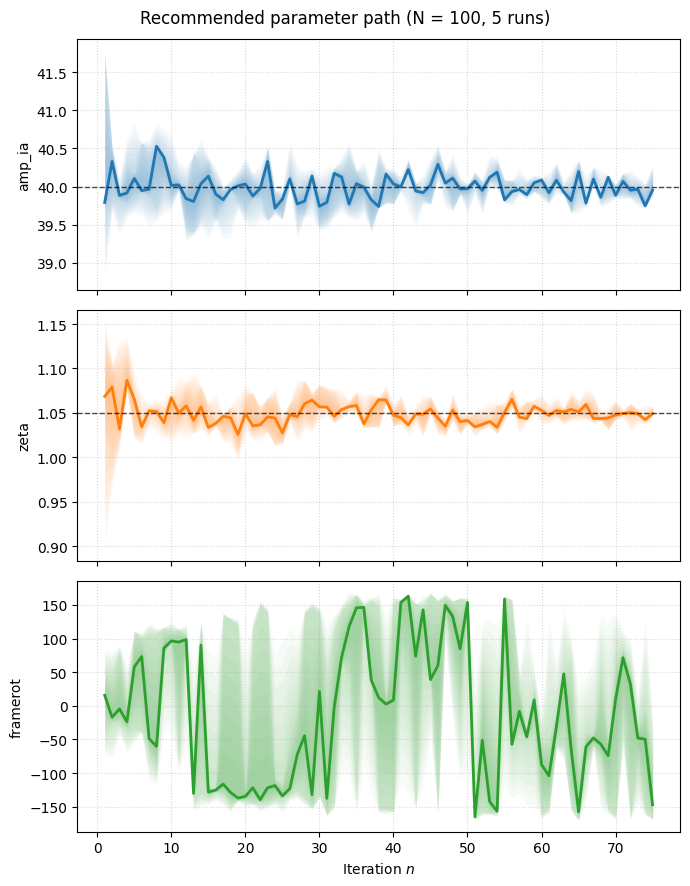

In [11]:
# Per-parameter recommended path for a single N (3 stacked panels)
PARAM_PATH_N = 100                      # choose any value in N_LIST
rows = [r for r in all_runs if r["N"] == PARAM_PATH_N]
phys = np.array(
    [[u_to_physical(r["X_opt"][:, k]) for k in range(r["X_opt"].shape[1])] for r in rows]
)                                         # (n_runs, n_iter, 3)
n = np.arange(1, phys.shape[1] + 1)
names = ["amp_ia", "zeta", "framerot"]
opt_ref = {"amp_ia": 40.0, "zeta": 1.05}  # implied by the error model; framerot unconstrained

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
for j, (axp, name) in enumerate(zip(axes, names)):
    layered_band(axp, n, phys[:, :, j], color=f"C{j}")
    if name in opt_ref:
        axp.axhline(opt_ref[name], color="k", ls="--", lw=1.0, alpha=0.7)
    axp.set_ylabel(name)
    axp.grid(True, ls=":", alpha=0.5)

axes[-1].set_xlabel("Iteration $n$")
fig.suptitle(f"Recommended parameter path (N = {PARAM_PATH_N}, {len(rows)} runs)")
plt.tight_layout()
plt.show()